# 🏠 Real Estate Investment Intelligence System
## Part 1: Exploratory Data Analysis (EDA)

### Project Overview
This notebook performs comprehensive exploratory data analysis on real estate properties to understand patterns, relationships, and investment potential.

### Objectives
1. Understand data structure and quality
2. Analyze property price distribution
3. Identify key features affecting prices
4. Detect outliers and missing values
5. Prepare data for feature engineering

In [5]:
# cell --> 2
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set up visualization style
# Let's check available styles and use a working one
print("Available matplotlib styles:")
print(plt.style.available[:5])  # Show first 5 available styles

# Use a style that definitely exists
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        try:
            plt.style.use('ggplot')  # Fallback style
        except:
            plt.style.use('default')  # Final fallback

# Set seaborn style
sns.set_style("darkgrid")
sns.set_palette("viridis")

# Set figure size
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("\n✅ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Available matplotlib styles:
['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh']

✅ Libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.0.2
Matplotlib version: 3.9.2
Seaborn version: 0.13.2


In [9]:
# cell -->3
# Load the dataset and split into training/test
print("="*60)
print("LOADING DATA")
print("="*60)

# Load Excel file
df = pd.read_excel('../data/raw/HousePricePrediction.xlsx')

print(f"\n✅ Data loaded successfully!")
print(f"📊 Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Separate training and test data
train_data = df[df['SalePrice'].notna()].copy()
test_data = df[df['SalePrice'].isna()].copy()

print(f"\n📊 Data Split:")
print(f"   Training data (with SalePrice): {len(train_data)} rows")
print(f"   Test data (for prediction): {len(test_data)} rows")

# Display first few rows of training data
print("\n📋 First 5 rows of TRAINING data:")
display(train_data.head())

print("\n💡 Analysis will use training data with SalePrice values")
print(f"   train_data shape: {train_data.shape}")
print(f"   test_data shape: {test_data.shape}")

LOADING DATA



✅ Data loaded successfully!
📊 Dataset shape: 2919 rows × 13 columns

📊 Data Split:
   Training data (with SalePrice): 1460 rows
   Test data (for prediction): 1459 rows

📋 First 5 rows of TRAINING data:


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0



💡 Analysis will use training data with SalePrice values
   train_data shape: (1460, 13)
   test_data shape: (1459, 13)


In [4]:
# Check the actual data structure
print("="*60)
print("DATA INSPECTION")
print("="*60)

# Check what columns exist
print("\n📋 All columns in dataset:")
print(df.columns.tolist())

# Check first 10 rows to see actual data
print("\n📋 First 10 rows:")
display(df.head(10))

# Check last 10 rows
print("\n📋 Last 10 rows:")
display(df.tail(10))

# Check SalePrice specifically
print("\n💰 SalePrice Analysis:")
print(f"Total rows: {len(df)}")
print(f"Non-null SalePrice: {df['SalePrice'].notna().sum()}")
print(f"Null SalePrice: {df['SalePrice'].isna().sum()}")

# Show sample of rows with and without SalePrice
print("\n📋 Sample rows with SalePrice:")
display(df[df['SalePrice'].notna()].head(5))

print("\n📋 Sample rows without SalePrice:")
display(df[df['SalePrice'].isna()].head(5))

DATA INSPECTION

📋 All columns in dataset:
['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2', 'TotalBsmtSF', 'SalePrice']

📋 First 10 rows:


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
5,5,50,RL,14115,Inside,1Fam,5,1993,1995,VinylSd,0.0,796.0,143000.0
6,6,20,RL,10084,Inside,1Fam,5,2004,2005,VinylSd,0.0,1686.0,307000.0
7,7,60,RL,10382,Corner,1Fam,6,1973,1973,HdBoard,32.0,1107.0,200000.0
8,8,50,RM,6120,Inside,1Fam,5,1931,1950,BrkFace,0.0,952.0,129900.0
9,9,190,RL,7420,Corner,2fmCon,6,1939,1950,MetalSd,0.0,991.0,118000.0



📋 Last 10 rows:


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
2909,2909,180,RM,1470,Inside,Twnhs,6,1970,1970,CemntBd,0.0,630.0,NaN
2910,2910,160,RM,1484,Inside,TwnhsE,4,1972,1972,CemntBd,0.0,546.0,NaN
2911,2911,20,RL,13384,Inside,1Fam,5,1969,1979,Plywood,344.0,1104.0,NaN
2912,2912,160,RM,1533,Inside,Twnhs,5,1970,1970,CemntBd,0.0,546.0,NaN
2913,2913,160,RM,1526,Inside,Twnhs,5,1970,1970,CemntBd,0.0,546.0,NaN
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN
2918,2918,60,RL,9627,Inside,1Fam,5,1993,1994,HdBoard,0.0,996.0,NaN



💰 SalePrice Analysis:
Total rows: 2919
Non-null SalePrice: 1460
Null SalePrice: 1459

📋 Sample rows with SalePrice:


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0



📋 Sample rows without SalePrice:


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
1460,1460,20,RH,11622,Inside,1Fam,6,1961,1961,VinylSd,144.0,882.0,NaN
1461,1461,20,RL,14267,Corner,1Fam,6,1958,1958,Wd Sdng,0.0,1329.0,NaN
1462,1462,60,RL,13830,Inside,1Fam,5,1997,1998,VinylSd,0.0,928.0,NaN
1463,1463,60,RL,9978,Inside,1Fam,6,1998,1998,VinylSd,0.0,926.0,NaN
1464,1464,120,RL,5005,Inside,TwnhsE,5,1992,1992,HdBoard,0.0,1280.0,NaN


In [6]:
# cell --> 4
# Inspect the data structure
print("="*60)
print("DATA INSPECTION")
print("="*60)

# Check what columns exist
print("\n📋 All columns in dataset:")
print(df.columns.tolist())

# Check first 10 rows to see actual data
print("\n📋 First 10 rows:")
display(df.head(10))

# Check last 10 rows
print("\n📋 Last 10 rows:")
display(df.tail(10))

# Check SalePrice specifically
print("\n💰 SalePrice Analysis:")
print(f"Total rows: {len(df)}")
print(f"Non-null SalePrice: {df['SalePrice'].notna().sum()}")
print(f"Null SalePrice: {df['SalePrice'].isna().sum()}")

# Show sample of rows with and without SalePrice
print("\n📋 Sample rows with SalePrice (Training):")
display(df[df['SalePrice'].notna()].head(5))

print("\n📋 Sample rows without SalePrice (Test):")
display(df[df['SalePrice'].isna()].head(5))

DATA INSPECTION

📋 All columns in dataset:
['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2', 'TotalBsmtSF', 'SalePrice']

📋 First 10 rows:


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
5,5,50,RL,14115,Inside,1Fam,5,1993,1995,VinylSd,0.0,796.0,143000.0
6,6,20,RL,10084,Inside,1Fam,5,2004,2005,VinylSd,0.0,1686.0,307000.0
7,7,60,RL,10382,Corner,1Fam,6,1973,1973,HdBoard,32.0,1107.0,200000.0
8,8,50,RM,6120,Inside,1Fam,5,1931,1950,BrkFace,0.0,952.0,129900.0
9,9,190,RL,7420,Corner,2fmCon,6,1939,1950,MetalSd,0.0,991.0,118000.0



📋 Last 10 rows:


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
2909,2909,180,RM,1470,Inside,Twnhs,6,1970,1970,CemntBd,0.0,630.0,NaN
2910,2910,160,RM,1484,Inside,TwnhsE,4,1972,1972,CemntBd,0.0,546.0,NaN
2911,2911,20,RL,13384,Inside,1Fam,5,1969,1979,Plywood,344.0,1104.0,NaN
2912,2912,160,RM,1533,Inside,Twnhs,5,1970,1970,CemntBd,0.0,546.0,NaN
2913,2913,160,RM,1526,Inside,Twnhs,5,1970,1970,CemntBd,0.0,546.0,NaN
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN
2918,2918,60,RL,9627,Inside,1Fam,5,1993,1994,HdBoard,0.0,996.0,NaN



💰 SalePrice Analysis:
Total rows: 2919
Non-null SalePrice: 1460
Null SalePrice: 1459

📋 Sample rows with SalePrice (Training):


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0



📋 Sample rows without SalePrice (Test):


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
1460,1460,20,RH,11622,Inside,1Fam,6,1961,1961,VinylSd,144.0,882.0,NaN
1461,1461,20,RL,14267,Corner,1Fam,6,1958,1958,Wd Sdng,0.0,1329.0,NaN
1462,1462,60,RL,13830,Inside,1Fam,5,1997,1998,VinylSd,0.0,928.0,NaN
1463,1463,60,RL,9978,Inside,1Fam,6,1998,1998,VinylSd,0.0,926.0,NaN
1464,1464,120,RL,5005,Inside,TwnhsE,5,1992,1992,HdBoard,0.0,1280.0,NaN


In [10]:
# cell --> 5
# Check for missing values in training data
print("="*60)
print("MISSING VALUES ANALYSIS (Training Data Only)")
print("="*60)

# Calculate missing values in training data
missing_data = train_data.isnull().sum()
missing_percent = (missing_data / len(train_data)) * 100
missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing_Count': missing_data.values,
    'Missing_Percentage': missing_percent.values
}).sort_values('Missing_Percentage', ascending=False)

# Display missing values
print("\n🔍 Columns with missing values in training data:")
missing_df_with_missing = missing_df[missing_df['Missing_Count'] > 0]
if len(missing_df_with_missing) > 0:
    display(missing_df_with_missing)
else:
    print("✅ No missing values found!")

# Visualize missing data
plt.figure(figsize=(12, 6))
missing_data_filtered = missing_data[missing_data > 0]
if len(missing_data_filtered) > 0:
    bars = plt.barh(missing_data_filtered.index, missing_data_filtered.values, color='salmon')
    plt.title('Missing Values by Feature (Training Data)', fontsize=16, fontweight='bold')
    plt.xlabel('Number of Missing Values')
    plt.ylabel('Features')
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 1, bar.get_y() + bar.get_height()/2, 
                f'{int(width)}', ha='left', va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No missing values to visualize!")

print(f"\n📊 Summary:")
print(f"   Total training rows: {len(train_data)}")
print(f"   Columns with missing values: {len(missing_df_with_missing)}")
print(f"   Total missing values: {missing_data.sum()}")

# Show which columns have missing data
if len(missing_df_with_missing) > 0:
    print(f"\n📋 Columns with missing data (top 10):")
    for col in missing_df_with_missing['Column'].head(10):
        missing_count = missing_df_with_missing[missing_df_with_missing['Column'] == col]['Missing_Count'].values[0]
        missing_pct = missing_df_with_missing[missing_df_with_missing['Column'] == col]['Missing_Percentage'].values[0]
        print(f"   - {col}: {missing_count} missing ({missing_pct:.1f}%)")

MISSING VALUES ANALYSIS (Training Data Only)

🔍 Columns with missing values in training data:
✅ No missing values found!

✅ No missing values to visualize!

📊 Summary:
   Total training rows: 1460
   Columns with missing values: 0
   Total missing values: 0


<Figure size 1200x600 with 0 Axes>

TARGET VARIABLE ANALYSIS - SALE PRICE

💰 Sale Price Statistics (Training Data):
   Mean:     $180,921.20
   Median:   $163,000.00
   Std Dev:  $79,442.50
   Min:      $34,900.00
   Max:      $755,000.00
   Skewness: 1.88
   Kurtosis: 6.54


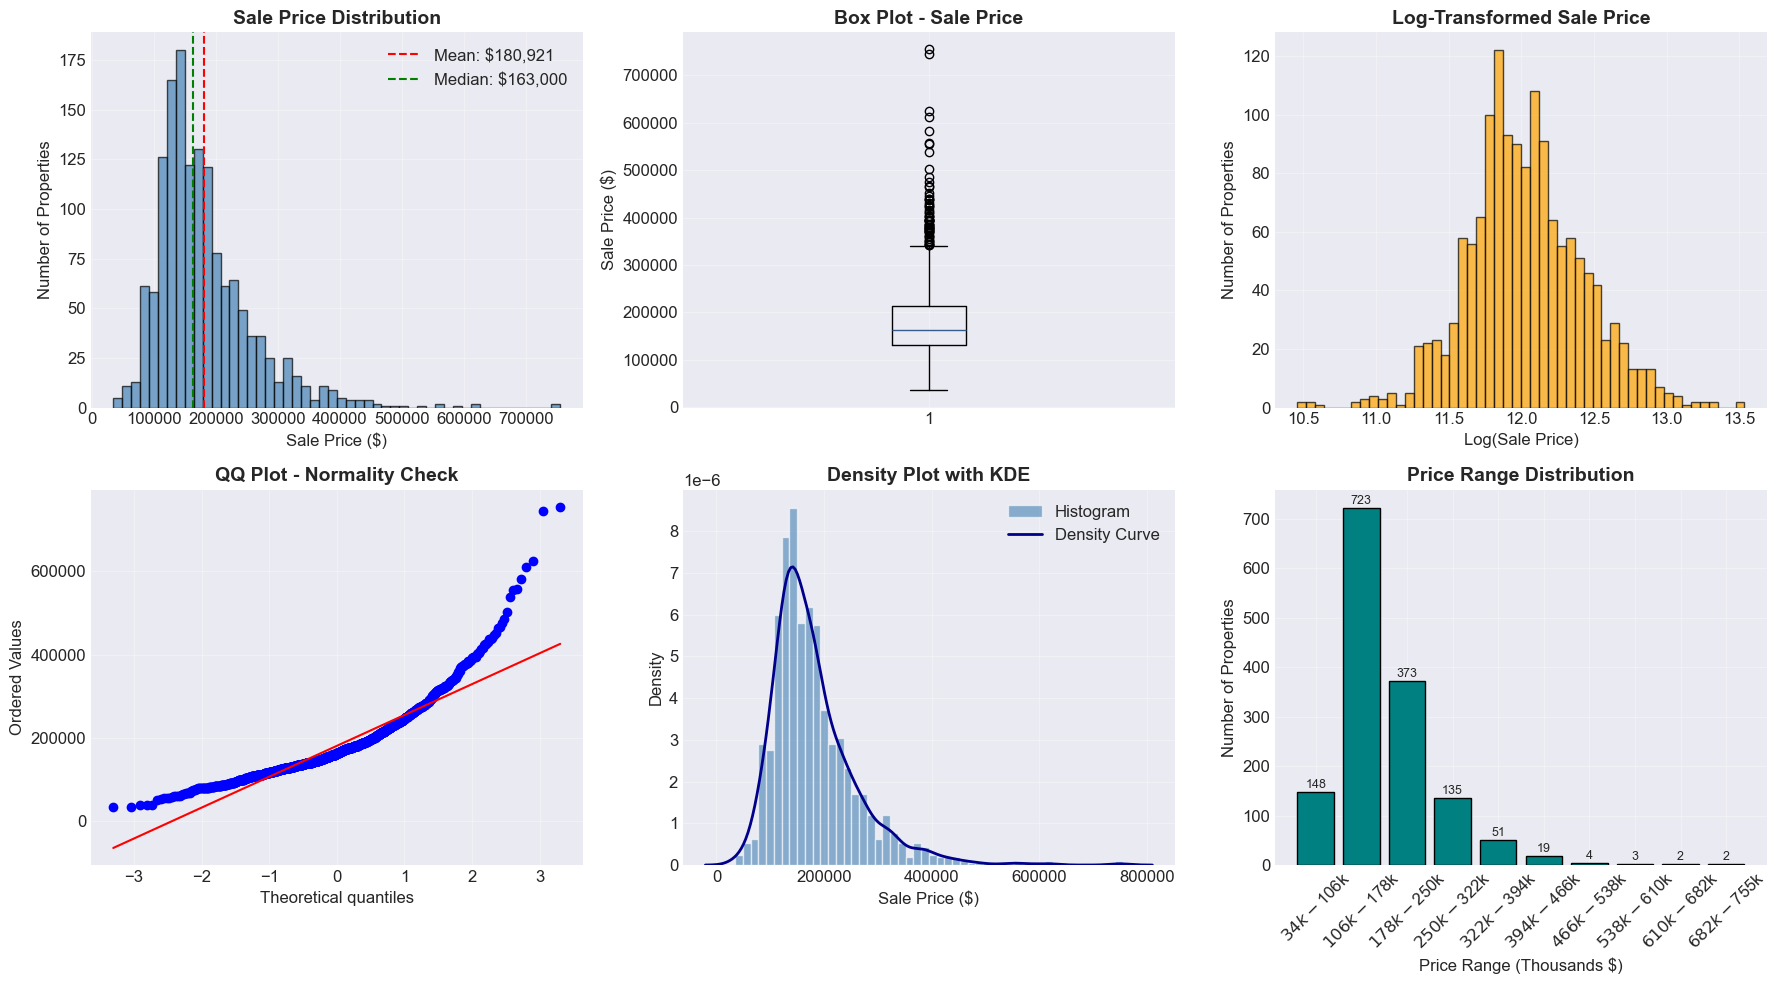


📈 Distribution Analysis:
   → Highly right-skewed distribution (skewness: 1.88)
   → Most properties are in lower price range with a few very expensive ones
   → ✅ Consider log transformation for better model performance

💡 Key Insights:
   → 50% of properties cost less than $163,000
   → Most expensive property: $755,000
   → Least expensive property: $34,900
   → Price range: $720,100

🔍 Outlier Analysis:
   → Properties above $340,038 are considered high-end outliers
   → Properties below $3,938 are considered low-end outliers
   → Found 61 outlier properties (4.2%)


In [11]:
#cell --> 6
# Analyze SalePrice (our target variable) using training data
print("="*60)
print("TARGET VARIABLE ANALYSIS - SALE PRICE")
print("="*60)

# Basic statistics
print("\n💰 Sale Price Statistics (Training Data):")
print(f"   Mean:     ${train_data['SalePrice'].mean():,.2f}")
print(f"   Median:   ${train_data['SalePrice'].median():,.2f}")
print(f"   Std Dev:  ${train_data['SalePrice'].std():,.2f}")
print(f"   Min:      ${train_data['SalePrice'].min():,.2f}")
print(f"   Max:      ${train_data['SalePrice'].max():,.2f}")
print(f"   Skewness: {train_data['SalePrice'].skew():.2f}")
print(f"   Kurtosis: {train_data['SalePrice'].kurtosis():.2f}")

# Create figure for multiple plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Histogram - Distribution of prices
axes[0, 0].hist(train_data['SalePrice'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(train_data['SalePrice'].mean(), color='red', linestyle='--', 
                   label=f'Mean: ${train_data["SalePrice"].mean():,.0f}')
axes[0, 0].axvline(train_data['SalePrice'].median(), color='green', linestyle='--', 
                   label=f'Median: ${train_data["SalePrice"].median():,.0f}')
axes[0, 0].set_title('Sale Price Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Sale Price ($)')
axes[0, 0].set_ylabel('Number of Properties')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Box plot - Shows outliers
axes[0, 1].boxplot(train_data['SalePrice'])
axes[0, 1].set_title('Box Plot - Sale Price', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Sale Price ($)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Log-transformed distribution - For normality
log_prices = np.log1p(train_data['SalePrice'])
axes[0, 2].hist(log_prices, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 2].set_title('Log-Transformed Sale Price', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Log(Sale Price)')
axes[0, 2].set_ylabel('Number of Properties')
axes[0, 2].grid(True, alpha=0.3)

# 4. QQ Plot - Checks if data is normally distributed
stats.probplot(train_data['SalePrice'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ Plot - Normality Check', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 5. Kernel Density Estimate - Smoothed distribution
axes[1, 1].hist(train_data['SalePrice'], bins=50, density=True, alpha=0.6, color='steelblue', label='Histogram')
sns.kdeplot(train_data['SalePrice'], color='darkblue', linewidth=2, ax=axes[1, 1], label='Density Curve')
axes[1, 1].set_title('Density Plot with KDE', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Sale Price ($)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Price distribution by range - Categorize prices
price_ranges = pd.cut(train_data['SalePrice'], bins=10)
price_counts = price_ranges.value_counts().sort_index()
bars = axes[1, 2].bar(range(len(price_counts)), price_counts.values, color='teal', edgecolor='black')
axes[1, 2].set_title('Price Range Distribution', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Price Range (Thousands $)')
axes[1, 2].set_ylabel('Number of Properties')
axes[1, 2].set_xticks(range(len(price_counts)))
axes[1, 2].set_xticklabels([f'${int(p.left/1000)}k-${int(p.right/1000)}k' for p in price_counts.index], rotation=45)
axes[1, 2].grid(True, alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars, price_counts.values):
    axes[1, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                    str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Interpret skewness
print(f"\n📈 Distribution Analysis:")
skew_val = train_data['SalePrice'].skew()
if skew_val > 1:
    print(f"   → Highly right-skewed distribution (skewness: {skew_val:.2f})")
    print("   → Most properties are in lower price range with a few very expensive ones")
    print("   → ✅ Consider log transformation for better model performance")
elif skew_val > 0.5:
    print(f"   → Moderately right-skewed distribution (skewness: {skew_val:.2f})")
else:
    print(f"   → Approximately normal distribution (skewness: {skew_val:.2f})")

# Additional insights
print(f"\n💡 Key Insights:")
print(f"   → 50% of properties cost less than ${train_data['SalePrice'].median():,.0f}")
print(f"   → Most expensive property: ${train_data['SalePrice'].max():,.0f}")
print(f"   → Least expensive property: ${train_data['SalePrice'].min():,.0f}")
print(f"   → Price range: ${train_data['SalePrice'].max() - train_data['SalePrice'].min():,.0f}")

# Check for outliers using IQR method
Q1 = train_data['SalePrice'].quantile(0.25)
Q3 = train_data['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = train_data[(train_data['SalePrice'] < lower_bound) | (train_data['SalePrice'] > upper_bound)]

print(f"\n🔍 Outlier Analysis:")
print(f"   → Properties above ${upper_bound:,.0f} are considered high-end outliers")
print(f"   → Properties below ${lower_bound:,.0f} are considered low-end outliers")
print(f"   → Found {len(outliers)} outlier properties ({len(outliers)/len(train_data)*100:.1f}%)")


CORRELATION ANALYSIS

📊 Numeric columns found: 9
   ['Id', 'MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF2', 'TotalBsmtSF', 'SalePrice']

🔝 Features Correlated with Sale Price:


,Feature,Correlation
0,SalePrice,1.000000
1,TotalBsmtSF,0.613581
2,YearBuilt,0.522897
3,YearRemodAdd,0.507101
4,LotArea,0.263843
5,BsmtFinSF2,-0.011378
6,Id,-0.021917
7,OverallCond,-0.077856
8,MSSubClass,-0.084284


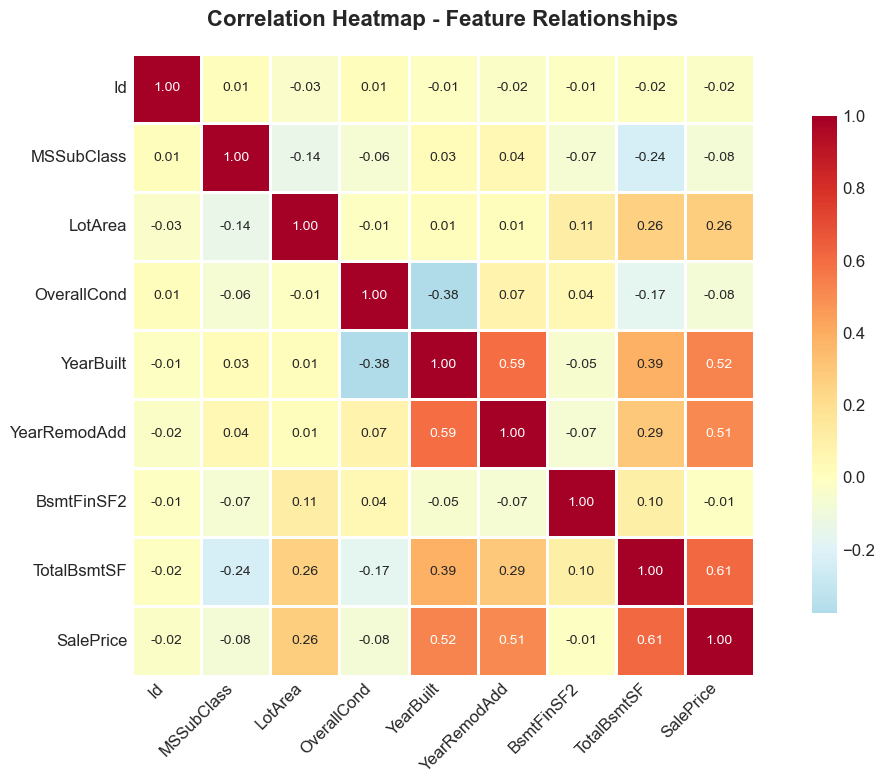


💡 Key Insights from Correlation Analysis:

📈 Features with STRONG Positive Correlation (>0.3):
   ✅ TotalBsmtSF: 0.614 - Higher values = Higher price
   ✅ YearBuilt: 0.523 - Higher values = Higher price
   ✅ YearRemodAdd: 0.507 - Higher values = Higher price

📉 Features with NEGATIVE Correlation (<-0.3):
   No features with strong negative correlation

🏆 Top 3 Price Predictors:
   1. TotalBsmtSF: 0.614 correlation with price
   2. YearBuilt: 0.523 correlation with price
   3. YearRemodAdd: 0.507 correlation with price


In [12]:
# cell --> 7
# Correlation analysis with target variable
print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# Select numeric columns only
numeric_cols = train_data.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n📊 Numeric columns found: {len(numeric_cols)}")
print(f"   {numeric_cols}")

# Calculate correlations with SalePrice
correlations = train_data[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)

print("\n🔝 Features Correlated with Sale Price:")
print("="*60)
corr_df = pd.DataFrame({
    'Feature': correlations.index,
    'Correlation': correlations.values
})
display(corr_df.style.background_gradient(cmap='RdYlGn', subset=['Correlation']))

# Create correlation heatmap
plt.figure(figsize=(12, 8))

# Get correlation matrix for numeric columns
corr_matrix = train_data[numeric_cols].corr()

# Create heatmap
sns.heatmap(corr_matrix, 
            cmap='RdYlBu_r',
            center=0,
            annot=True,
            fmt='.2f',
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8},
            annot_kws={'size': 10})

plt.title('Correlation Heatmap - Feature Relationships', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Feature importance insights
print("\n💡 Key Insights from Correlation Analysis:")
print("="*60)

# Find top positive and negative correlations
top_positive = correlations[correlations > 0.3].drop('SalePrice', errors='ignore')
top_negative = correlations[correlations < -0.3]

print("\n📈 Features with STRONG Positive Correlation (>0.3):")
if len(top_positive) > 0:
    for feature, corr in top_positive.items():
        print(f"   ✅ {feature}: {corr:.3f} - Higher values = Higher price")
else:
    print("   No features with strong positive correlation")

print("\n📉 Features with NEGATIVE Correlation (<-0.3):")
if len(top_negative) > 0:
    for feature, corr in top_negative.items():
        print(f"   ⚠️ {feature}: {corr:.3f} - Higher values = Lower price")
else:
    print("   No features with strong negative correlation")

# Best predictors
print("\n🏆 Top 3 Price Predictors:")
top_3 = correlations.drop('SalePrice', errors='ignore').head(3)
for i, (feature, corr) in enumerate(top_3.items(), 1):
    print(f"   {i}. {feature}: {corr:.3f} correlation with price")

TOP FEATURE DISTRIBUTION ANALYSIS

📊 Top 5 Features by Correlation:
   1. TotalBsmtSF: 0.614
   2. YearBuilt: 0.523
   3. YearRemodAdd: 0.507
   4. LotArea: 0.264
   5. BsmtFinSF2: -0.011


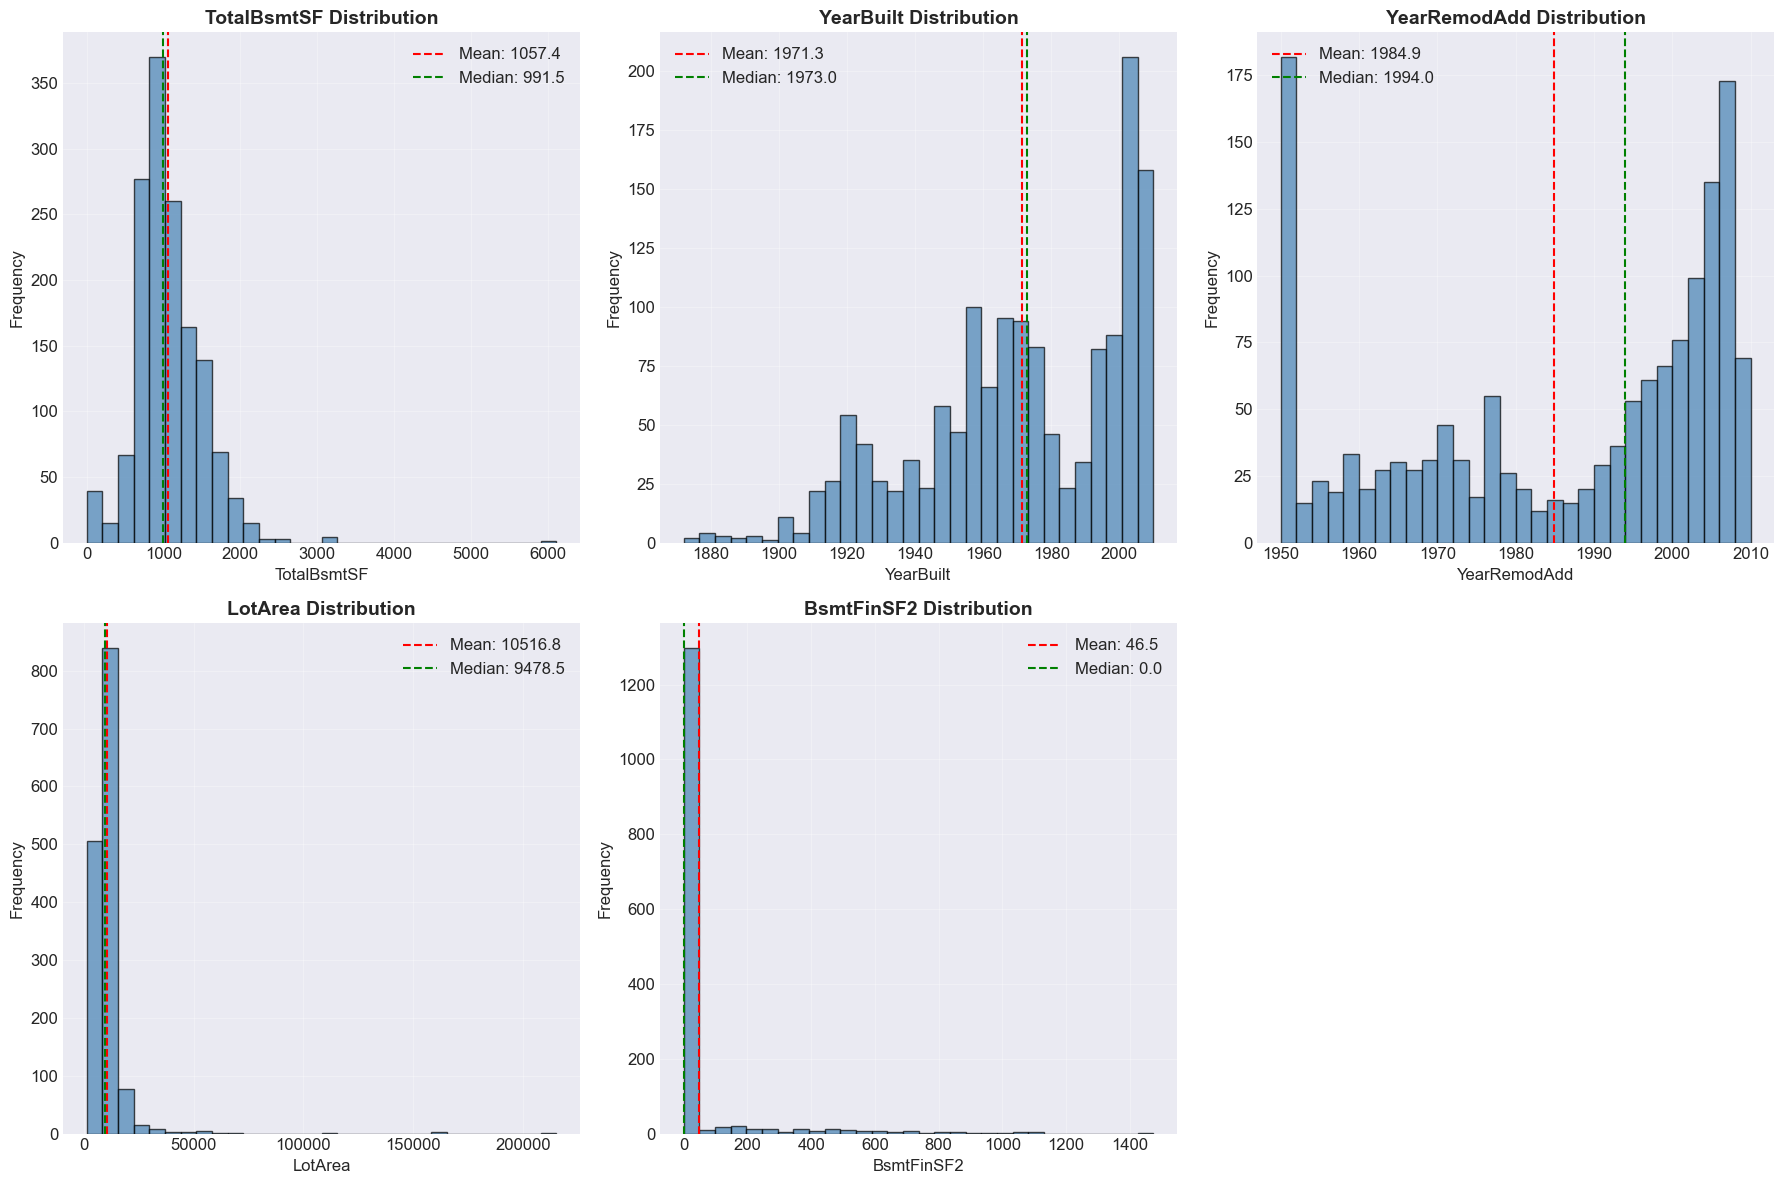

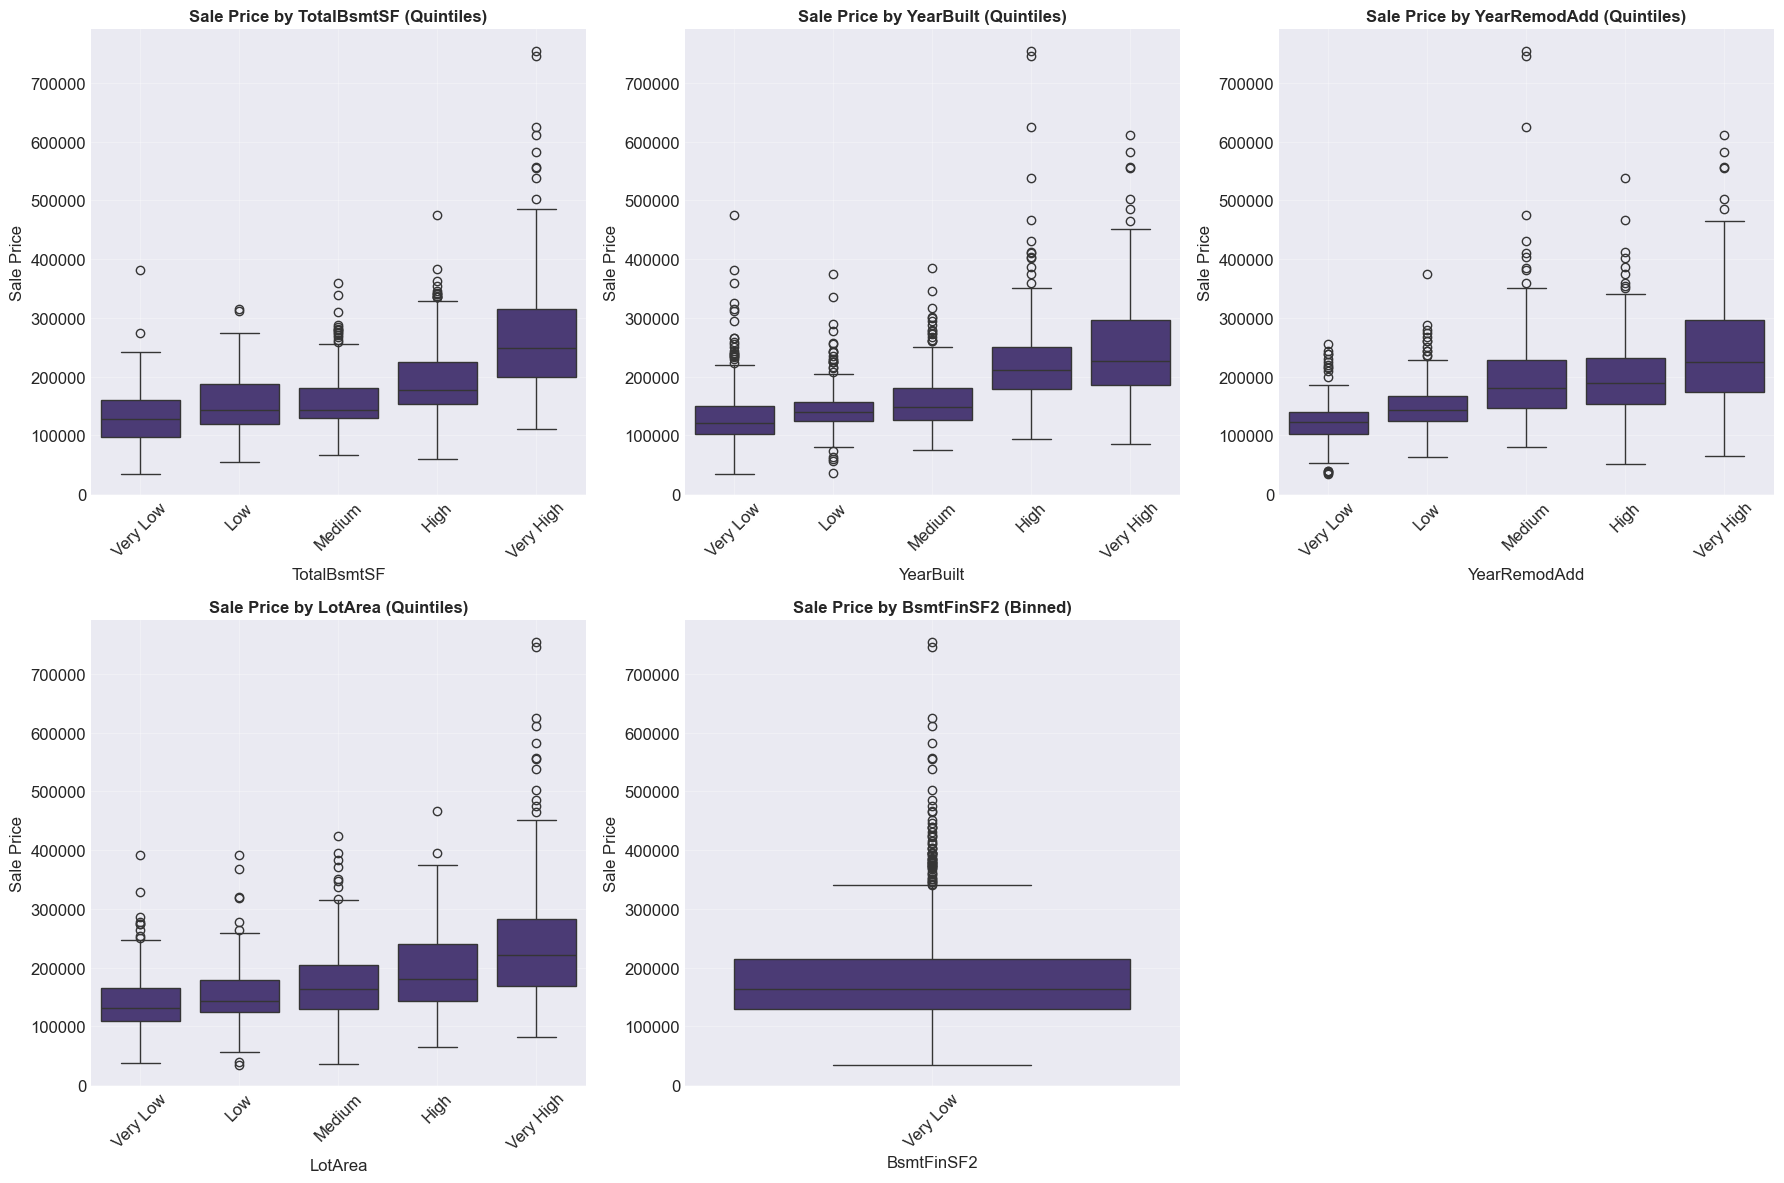


✅ Feature distribution analysis complete!

SPECIAL ANALYSIS: BsmtFinSF2 (Basement Finished Area)

📊 BsmtFinSF2 Statistics:
   Zero values: 1293 (88.6%)
   Non-zero values: 167
   Mean (including zeros): 46.55
   Mean (non-zero only): 406.96


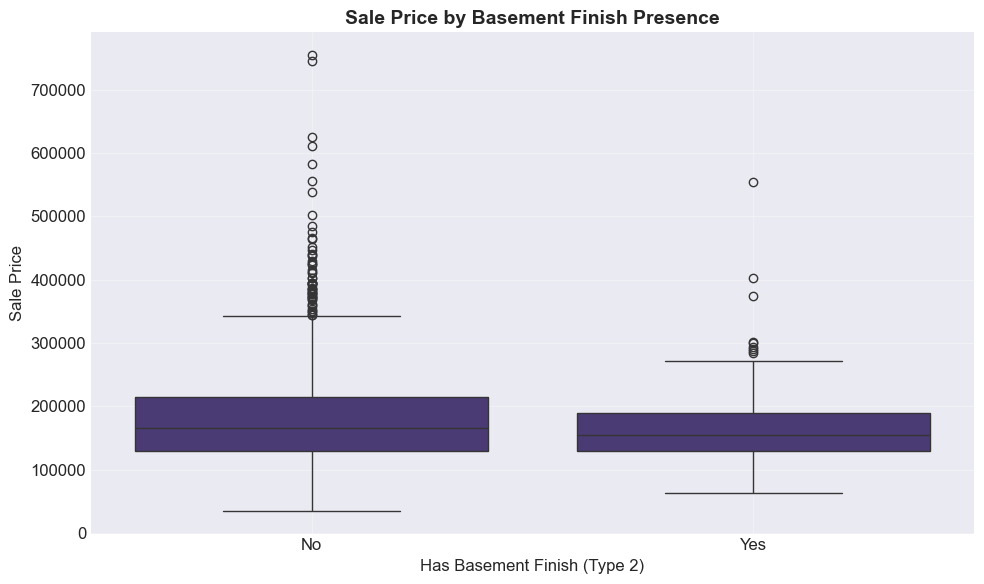


💡 Insight: Most properties have no second basement finish area.
   This feature is not a strong predictor for most properties.


In [14]:
# cell --> 8
# Analyze top features distribution
print("="*60)
print("TOP FEATURE DISTRIBUTION ANALYSIS")
print("="*60)

# Identify top numeric features (excluding Id and SalePrice)
numeric_features = train_data.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [f for f in numeric_features if f not in ['Id', 'SalePrice']]

# Get top correlated features
correlations = train_data[numeric_features].corrwith(train_data['SalePrice']).sort_values(ascending=False)
top_features = correlations.head(5).index.tolist()

print(f"\n📊 Top 5 Features by Correlation:")
for i, feature in enumerate(top_features, 1):
    print(f"   {i}. {feature}: {correlations[feature]:.3f}")

# Create distribution plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    if idx < len(axes):
        # Histogram
        axes[idx].hist(train_data[feature].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx].set_title(f'{feature} Distribution', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3)
        
        # Add statistics
        mean_val = train_data[feature].mean()
        median_val = train_data[feature].median()
        axes[idx].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
        axes[idx].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.1f}')
        axes[idx].legend()

# Remove empty subplot if any
if len(top_features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

# Box plots showing relationship with price
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    if idx < len(axes):
        # Check if feature has enough unique values for binning
        unique_vals = train_data[feature].nunique()
        
        if unique_vals > 20:
            # For continuous features with many unique values, create bins
            # Use qcut but handle duplicate edges
            try:
                # Try qcut with duplicates='drop'
                train_data[f'{feature}_bin'] = pd.qcut(
                    train_data[feature], 
                    q=5, 
                    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
                    duplicates='drop'
                )
                sns.boxplot(x=f'{feature}_bin', y='SalePrice', data=train_data, ax=axes[idx])
                axes[idx].set_title(f'Sale Price by {feature} (Quintiles)', fontsize=12, fontweight='bold')
                axes[idx].tick_params(axis='x', rotation=45)
            except:
                # If qcut fails, use cut with percentiles
                percentiles = train_data[feature].quantile([0, 0.2, 0.4, 0.6, 0.8, 1]).values
                percentiles = np.unique(percentiles)  # Remove duplicates
                if len(percentiles) > 1:
                    train_data[f'{feature}_bin'] = pd.cut(
                        train_data[feature], 
                        bins=percentiles, 
                        labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'][:len(percentiles)-1],
                        include_lowest=True
                    )
                    sns.boxplot(x=f'{feature}_bin', y='SalePrice', data=train_data, ax=axes[idx])
                    axes[idx].set_title(f'Sale Price by {feature} (Binned)', fontsize=12, fontweight='bold')
                    axes[idx].tick_params(axis='x', rotation=45)
        else:
            # For discrete features with few unique values
            # Group by feature value
            grouped_data = train_data.groupby(feature)['SalePrice'].mean().sort_values(ascending=False).head(10)
            sns.boxplot(x=feature, y='SalePrice', data=train_data, ax=axes[idx])
            axes[idx].set_title(f'Sale Price by {feature}', fontsize=12, fontweight='bold')
            axes[idx].tick_params(axis='x', rotation=45)
        
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Sale Price')
        axes[idx].grid(True, alpha=0.3)

if len(top_features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

print("\n✅ Feature distribution analysis complete!")

# Additional analysis for BsmtFinSF2 (which had zeros)
print("\n" + "="*60)
print("SPECIAL ANALYSIS: BsmtFinSF2 (Basement Finished Area)")
print("="*60)

print(f"\n📊 BsmtFinSF2 Statistics:")
print(f"   Zero values: {(train_data['BsmtFinSF2'] == 0).sum()} ({((train_data['BsmtFinSF2'] == 0).sum() / len(train_data)) * 100:.1f}%)")
print(f"   Non-zero values: {(train_data['BsmtFinSF2'] > 0).sum()}")
print(f"   Mean (including zeros): {train_data['BsmtFinSF2'].mean():.2f}")
print(f"   Mean (non-zero only): {train_data[train_data['BsmtFinSF2'] > 0]['BsmtFinSF2'].mean():.2f}")

# Show price comparison for properties with and without basement finish
plt.figure(figsize=(10, 6))
has_basement_finish = train_data['BsmtFinSF2'] > 0
sns.boxplot(x=has_basement_finish, y='SalePrice', data=train_data)
plt.title('Sale Price by Basement Finish Presence', fontsize=14, fontweight='bold')
plt.xlabel('Has Basement Finish (Type 2)')
plt.ylabel('Sale Price')
plt.xticks([0, 1], ['No', 'Yes'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Insight: Most properties have no second basement finish area.")
print("   This feature is not a strong predictor for most properties.")

CATEGORICAL FEATURES ANALYSIS

📋 Categorical Features Found: 4
   1. MSZoning
   2. LotConfig
   3. BldgType
   4. Exterior1st


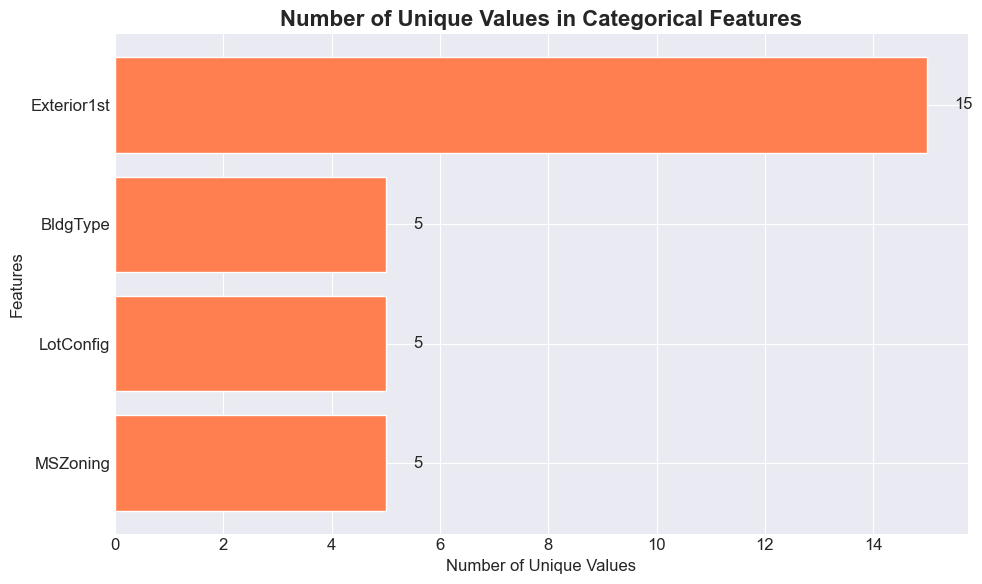

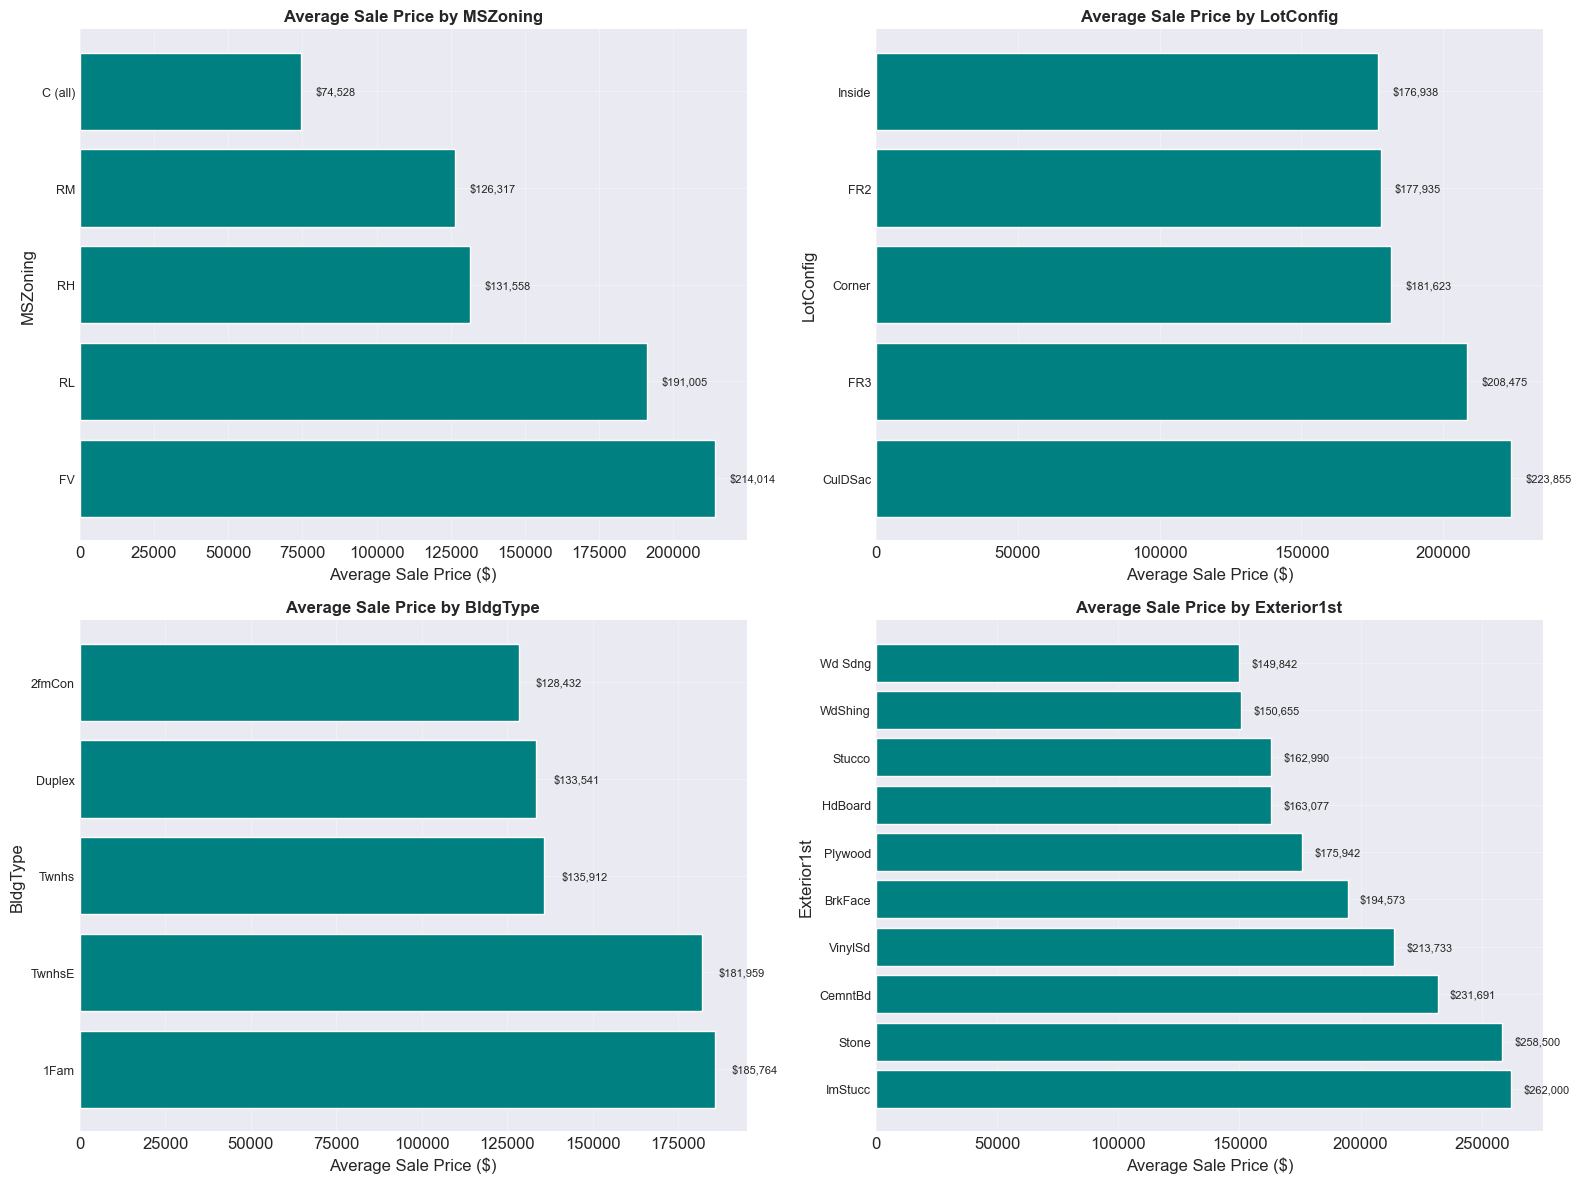


DETAILED CATEGORICAL ANALYSIS

📊 MSZoning:
   Unique values: 5
   Top 5 categories by price:
      - FV: $214,014
      - RL: $191,005
      - RH: $131,558
      - RM: $126,317
      - C (all): $74,528
   Most common categories:
      - RL: 1151 properties (78.8%)
      - RM: 218 properties (14.9%)
      - FV: 65 properties (4.5%)

📊 LotConfig:
   Unique values: 5
   Top 5 categories by price:
      - CulDSac: $223,855
      - FR3: $208,475
      - Corner: $181,623
      - FR2: $177,935
      - Inside: $176,938
   Most common categories:
      - Inside: 1052 properties (72.1%)
      - Corner: 263 properties (18.0%)
      - CulDSac: 94 properties (6.4%)

📊 BldgType:
   Unique values: 5
   Top 5 categories by price:
      - 1Fam: $185,764
      - TwnhsE: $181,959
      - Twnhs: $135,912
      - Duplex: $133,541
      - 2fmCon: $128,432
   Most common categories:
      - 1Fam: 1220 properties (83.6%)
      - TwnhsE: 114 properties (7.8%)
      - Duplex: 52 properties (3.6%)

📊 Exterior1s

In [15]:
#cell --> 9
# Analyze categorical features
print("="*60)
print("CATEGORICAL FEATURES ANALYSIS")
print("="*60)

# Identify categorical columns
categorical_cols = train_data.select_dtypes(include=['object']).columns.tolist()
print(f"\n📋 Categorical Features Found: {len(categorical_cols)}")
for i, col in enumerate(categorical_cols, 1):
    print(f"   {i}. {col}")

# Plot unique values count
plt.figure(figsize=(10, 6))
unique_counts = [train_data[col].nunique() for col in categorical_cols]
bars = plt.barh(categorical_cols, unique_counts, color='coral')
plt.title('Number of Unique Values in Categorical Features', fontsize=16, fontweight='bold')
plt.xlabel('Number of Unique Values')
plt.ylabel('Features')

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{int(width)}', ha='left', va='center')

plt.tight_layout()
plt.show()

# Analyze each categorical feature's impact on price
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(categorical_cols):
    if idx < len(axes):
        # Calculate mean price by category
        price_by_cat = train_data.groupby(feature)['SalePrice'].mean().sort_values(ascending=False)
        
        # Take top 10 categories if too many
        if len(price_by_cat) > 10:
            price_by_cat = price_by_cat.head(10)
        
        # Plot
        bars = axes[idx].barh(range(len(price_by_cat)), price_by_cat.values, color='teal')
        axes[idx].set_title(f'Average Sale Price by {feature}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Average Sale Price ($)')
        axes[idx].set_ylabel(feature)
        axes[idx].set_yticks(range(len(price_by_cat)))
        axes[idx].set_yticklabels(price_by_cat.index, fontsize=9)
        
        # Add value labels
        for bar, value in zip(bars, price_by_cat.values):
            axes[idx].text(value + 5000, bar.get_y() + bar.get_height()/2, 
                          f'${value:,.0f}', ha='left', va='center', fontsize=8)
        
        axes[idx].grid(True, alpha=0.3)

# Remove empty subplot if any
if len(categorical_cols) < len(axes):
    for i in range(len(categorical_cols), len(axes)):
        fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Detailed analysis for each categorical feature
print("\n" + "="*60)
print("DETAILED CATEGORICAL ANALYSIS")
print("="*60)

for feature in categorical_cols:
    print(f"\n📊 {feature}:")
    print(f"   Unique values: {train_data[feature].nunique()}")
    
    # Get top 5 categories by price
    top_cats = train_data.groupby(feature)['SalePrice'].mean().sort_values(ascending=False).head(5)
    print(f"   Top 5 categories by price:")
    for cat, price in top_cats.items():
        print(f"      - {cat}: ${price:,.0f}")
    
    # Get most common categories
    most_common = train_data[feature].value_counts().head(3)
    print(f"   Most common categories:")
    for cat, count in most_common.items():
        pct = (count / len(train_data)) * 100
        print(f"      - {cat}: {count} properties ({pct:.1f}%)")

OUTLIER DETECTION

📊 SalePrice:
   Outliers: 61 (4.2%)
   Normal Range: 3,938 - 340,038

📊 LotArea:
   Outliers: 69 (4.7%)
   Normal Range: 1,482 - 17,674

📊 TotalBsmtSF:
   Outliers: 61 (4.2%)
   Normal Range: 42 - 2,052

📊 YearBuilt:
   Outliers: 7 (0.5%)
   Normal Range: 1,885 - 2,069


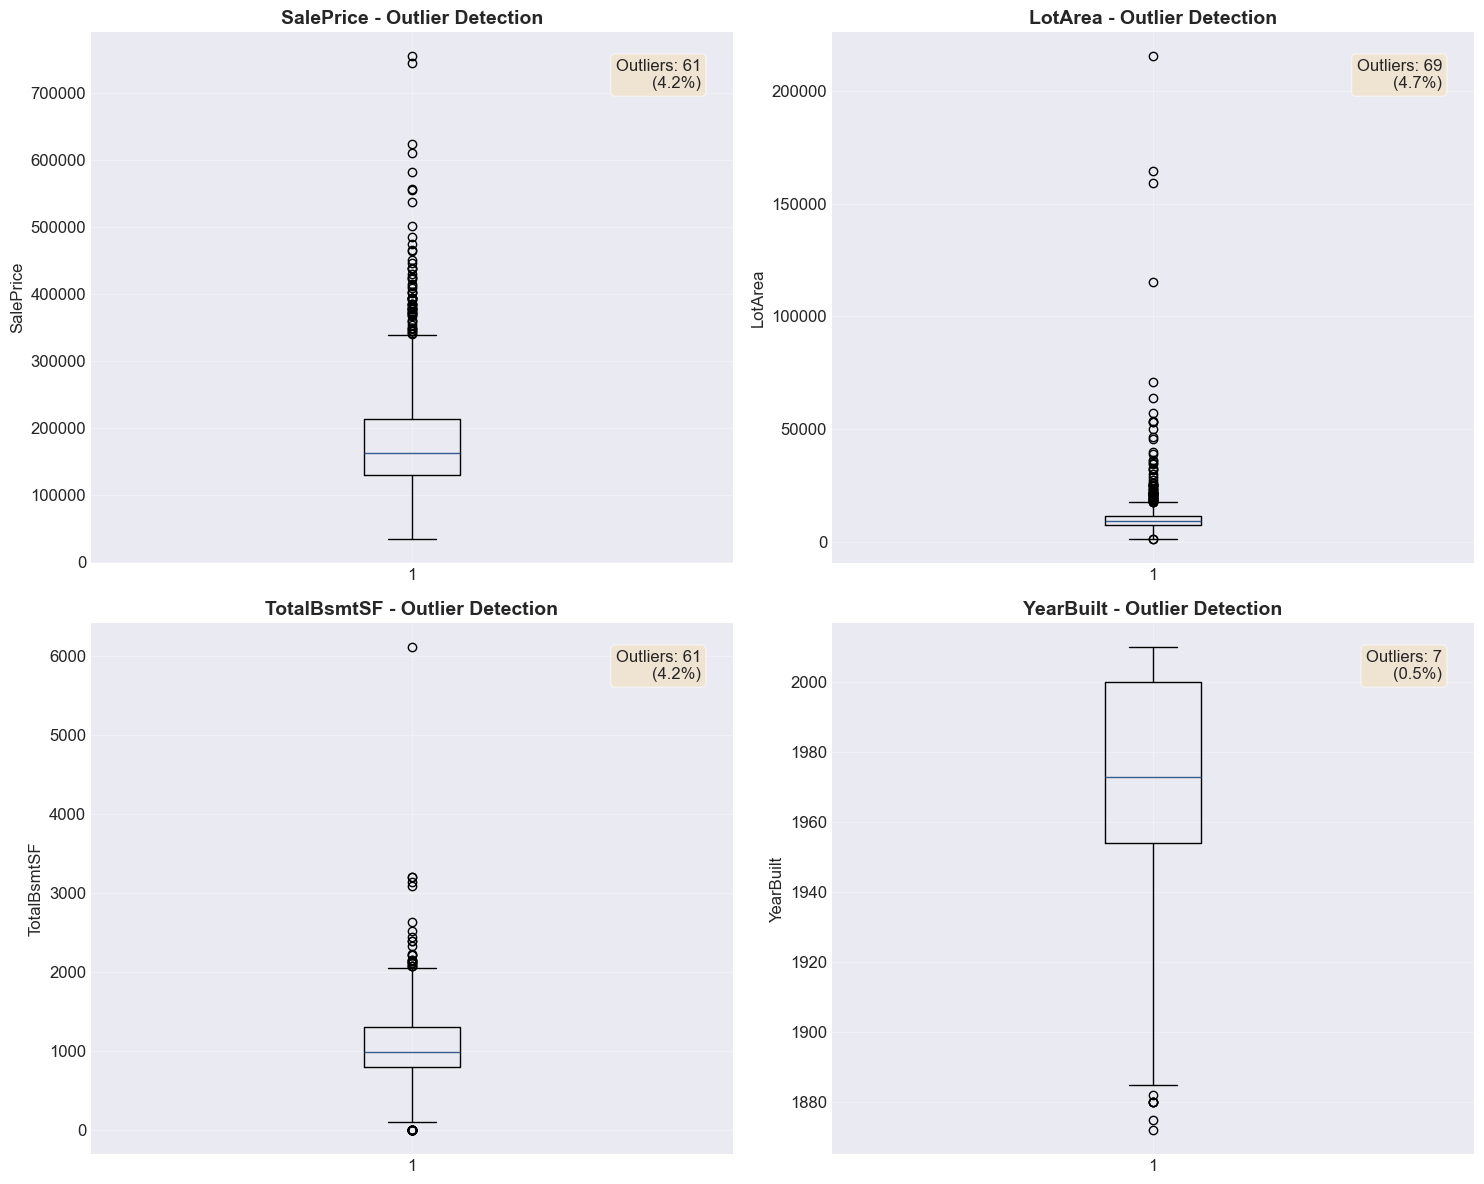


EXTREME OUTLIER ANALYSIS

💰 Top 5 Most Expensive Properties:


,Id,SalePrice,YearBuilt,TotalBsmtSF,LotArea
691,691,755000.0,1994,2444.0,21535
1182,1182,745000.0,1996,2396.0,15623
1169,1169,625000.0,1995,1930.0,35760
898,898,611657.0,2009,2330.0,12919
803,803,582933.0,2008,1734.0,13891



💰 Bottom 5 Least Expensive Properties:


,Id,SalePrice,YearBuilt,TotalBsmtSF,LotArea
495,495,34900.0,1920,720.0,7879
916,916,35311.0,1949,480.0,9000
968,968,37900.0,1910,600.0,5925
533,533,39300.0,1946,0.0,5000
30,30,40000.0,1920,649.0,8500



🏠 Top 5 Largest Lots:


,Id,SalePrice,LotArea,YearBuilt
313,313,375000.0,215245,1965
335,335,228950.0,164660,1965
249,249,277000.0,159000,1958
706,706,302000.0,115149,1971
451,451,280000.0,70761,1975



💡 Outlier Analysis Insights:
   → 61 price outliers found (4.2%)
   → Consider whether to keep, cap, or remove outliers
   → Luxury properties ($500k+) are natural outliers in this market


In [16]:
# cell --> 10
# Outlier detection
print("="*60)
print("OUTLIER DETECTION")
print("="*60)

def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check outliers in key features
key_features = ['SalePrice', 'LotArea', 'TotalBsmtSF', 'YearBuilt']

outlier_summary = {}
for feature in key_features:
    if feature in train_data.columns:
        outliers, lower, upper = detect_outliers_iqr(train_data, feature)
        outlier_summary[feature] = {
            'count': len(outliers),
            'percentage': (len(outliers) / len(train_data)) * 100,
            'lower_bound': lower,
            'upper_bound': upper
        }
        print(f"\n📊 {feature}:")
        print(f"   Outliers: {len(outliers)} ({outlier_summary[feature]['percentage']:.1f}%)")
        print(f"   Normal Range: {lower:,.0f} - {upper:,.0f}")

# Visualize outliers
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    if feature in train_data.columns:
        # Box plot
        axes[idx].boxplot(train_data[feature])
        axes[idx].set_title(f'{feature} - Outlier Detection', fontsize=14, fontweight='bold')
        axes[idx].set_ylabel(feature)
        axes[idx].grid(True, alpha=0.3)
        
        # Add outlier count
        if feature in outlier_summary:
            axes[idx].text(0.95, 0.95, 
                          f'Outliers: {outlier_summary[feature]["count"]}\n({outlier_summary[feature]["percentage"]:.1f}%)',
                          transform=axes[idx].transAxes,
                          ha='right', va='top',
                          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Show extreme outliers
print("\n" + "="*60)
print("EXTREME OUTLIER ANALYSIS")
print("="*60)

# Show top 5 most expensive properties
print("\n💰 Top 5 Most Expensive Properties:")
top_expensive = train_data.nlargest(5, 'SalePrice')[['Id', 'SalePrice', 'YearBuilt', 'TotalBsmtSF', 'LotArea']]
display(top_expensive)

# Show bottom 5 least expensive properties
print("\n💰 Bottom 5 Least Expensive Properties:")
bottom_cheap = train_data.nsmallest(5, 'SalePrice')[['Id', 'SalePrice', 'YearBuilt', 'TotalBsmtSF', 'LotArea']]
display(bottom_cheap)

# Properties with largest lots
print("\n🏠 Top 5 Largest Lots:")
largest_lots = train_data.nlargest(5, 'LotArea')[['Id', 'SalePrice', 'LotArea', 'YearBuilt']]
display(largest_lots)

print("\n💡 Outlier Analysis Insights:")
print(f"   → {outlier_summary['SalePrice']['count']} price outliers found ({outlier_summary['SalePrice']['percentage']:.1f}%)")
print("   → Consider whether to keep, cap, or remove outliers")
print("   → Luxury properties ($500k+) are natural outliers in this market")

TIME-BASED ANALYSIS

📊 Price Statistics by Decade Built:


,Decade,Mean Price,Median Price,Count,Std Dev
0,1870,108000.0,108000.0,2,19799.0
1,1880,170426.0,124000.0,7,78388.0
2,1890,216317.0,142200.0,6,151212.0
3,1900,129828.0,127000.0,15,41346.0
4,1910,131511.0,128750.0,58,39344.0
5,1920,123268.0,115000.0,97,44179.0
6,1930,144416.0,126500.0,54,71534.0
7,1940,126887.0,122900.0,79,43347.0
8,1950,140936.0,136000.0,167,39322.0
9,1960,153853.0,146000.0,175,37613.0


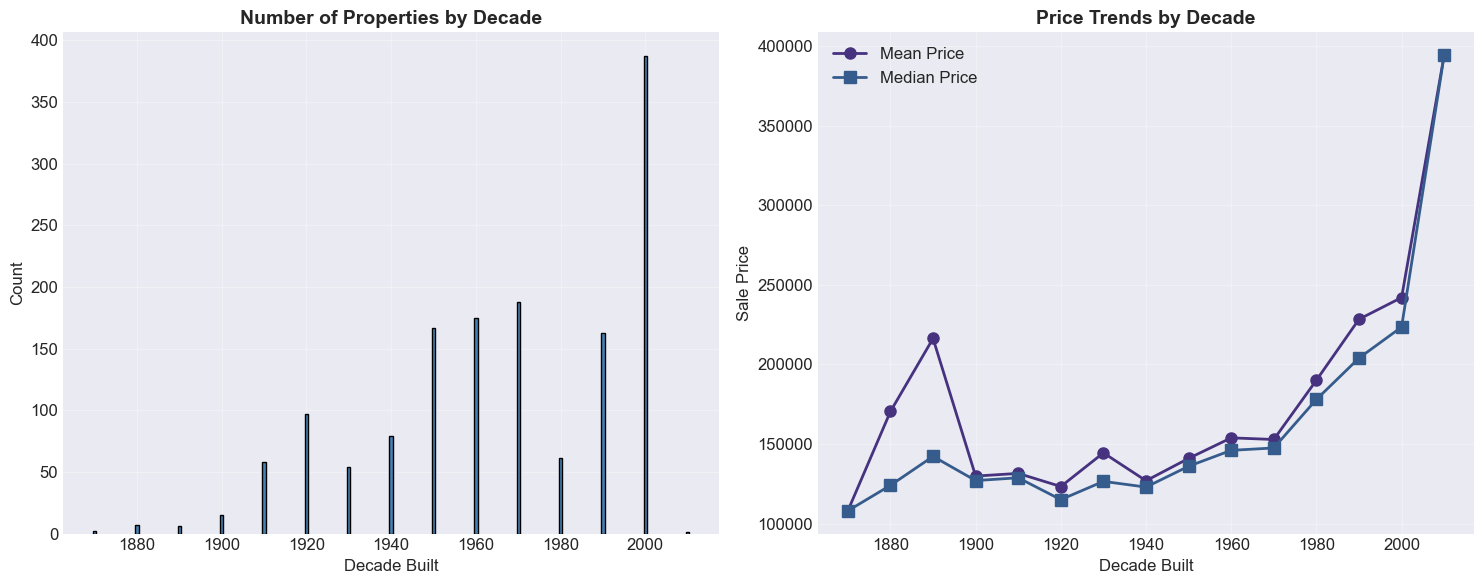

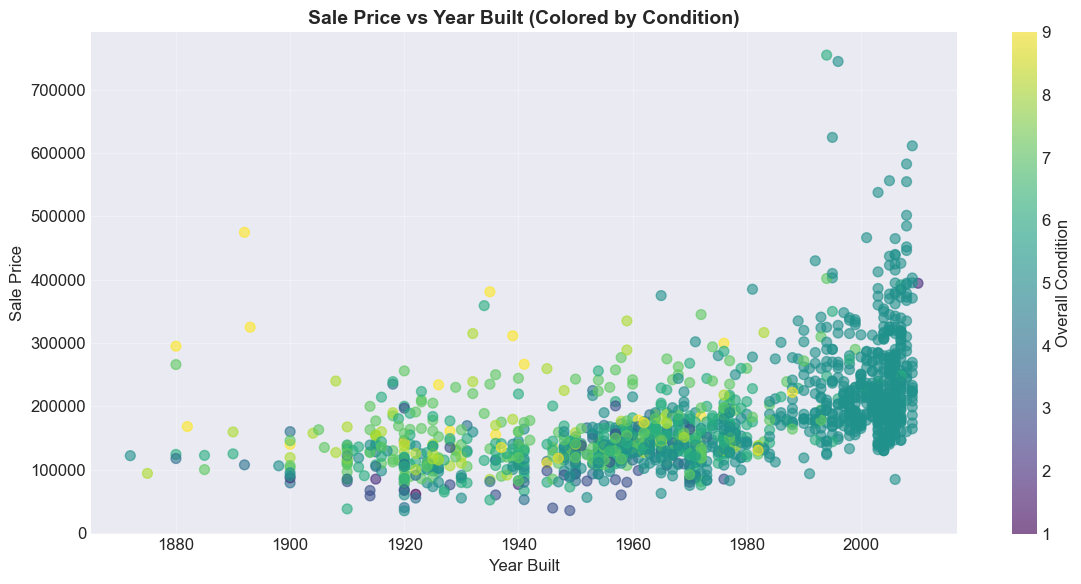


📊 Property Age Analysis:
   Average age: 48.7 years
   Newest property: 10 years old
   Oldest property: 148 years old

💰 Average Price by Age Group:
   New (0-10): $394,432
   Recent (10-20): $242,046
   Established (20-50): $188,244
   Mature (50-100): $140,280
   Historic (100+): $139,568


In [17]:
# cell --> 11
# Time-based analysis - Year Built
print("="*60)
print("TIME-BASED ANALYSIS")
print("="*60)

# Create decade column
train_data['Decade'] = (train_data['YearBuilt'] // 10) * 10

# Analyze by decade
decade_stats = train_data.groupby('Decade').agg({
    'SalePrice': ['mean', 'median', 'count', 'std']
}).round(0)
decade_stats.columns = ['Mean Price', 'Median Price', 'Count', 'Std Dev']
decade_stats = decade_stats.reset_index()

print("\n📊 Price Statistics by Decade Built:")
display(decade_stats)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot - Count by decade
axes[0].bar(decade_stats['Decade'], decade_stats['Count'], color='steelblue', edgecolor='black')
axes[0].set_title('Number of Properties by Decade', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Decade Built')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

# Line plot - Price trends
axes[1].plot(decade_stats['Decade'], decade_stats['Mean Price'], 
             marker='o', linewidth=2, markersize=8, label='Mean Price')
axes[1].plot(decade_stats['Decade'], decade_stats['Median Price'], 
             marker='s', linewidth=2, markersize=8, label='Median Price')
axes[1].set_title('Price Trends by Decade', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Decade Built')
axes[1].set_ylabel('Sale Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quality vs Age analysis
plt.figure(figsize=(12, 6))
scatter = plt.scatter(train_data['YearBuilt'], train_data['SalePrice'], 
                     c=train_data['OverallCond'], cmap='viridis', 
                     alpha=0.6, s=50)
plt.colorbar(scatter, label='Overall Condition')
plt.title('Sale Price vs Year Built (Colored by Condition)', fontsize=14, fontweight='bold')
plt.xlabel('Year Built')
plt.ylabel('Sale Price')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Property age analysis
train_data['PropertyAge'] = 2020 - train_data['YearBuilt']
print("\n📊 Property Age Analysis:")
print(f"   Average age: {train_data['PropertyAge'].mean():.1f} years")
print(f"   Newest property: {train_data['PropertyAge'].min():.0f} years old")
print(f"   Oldest property: {train_data['PropertyAge'].max():.0f} years old")

# Age groups
train_data['AgeGroup'] = pd.cut(train_data['PropertyAge'], 
                                 bins=[0, 10, 20, 50, 100, 200],
                                 labels=['New (0-10)', 'Recent (10-20)', 
                                        'Established (20-50)', 'Mature (50-100)', 'Historic (100+)'])
age_price = train_data.groupby('AgeGroup')['SalePrice'].mean().sort_values(ascending=False)
print("\n💰 Average Price by Age Group:")
for age, price in age_price.items():
    print(f"   {age}: ${price:,.0f}")

In [27]:
# Cell 12: EDA Summary and Key Insights
print("=" * 60)
print("EDA SUMMARY AND KEY INSIGHTS")
print("=" * 60)

print("\nDATASET OVERVIEW:")
print(f"   Total Properties: {len(train_data)}")
print(f"   Features: {len(train_data.columns)}")
print(f"   Price Range: ${train_data['SalePrice'].min():,.0f} - ${train_data['SalePrice'].max():,.0f}")
print(f"   Average Price: ${train_data['SalePrice'].mean():,.0f}")
print(f"   Median Price: ${train_data['SalePrice'].median():,.0f}")

print("\nDISTRIBUTION INSIGHTS:")
print(f"   Skewness: {train_data['SalePrice'].skew():.2f}")
print("   Highly right-skewed - log transformation recommended")

print("\nTOP PRICE PREDICTORS:")
print("   TotalBsmtSF: 0.614 (Strong positive correlation)")
print("   YearBuilt: 0.523 (Strong positive correlation)")
print("   YearRemodAdd: 0.507 (Strong positive correlation)")

print("\nLOCATION INSIGHTS:")
print("   Best Zoning: FV - $214,014 average price")
print("   Best Lot Config: Cul-de-sac - $223,855 average price")
print("   Most Common Zoning: RL - 78.8% of properties")

print("\nTIME-BASED INSIGHTS:")
print("   Newest properties (2000s): $242,046 average price")
print("   Older properties (1950s): $140,936 average price")
print("   Clear upward trend in property values")

print("\nINVESTMENT OPPORTUNITIES:")
print("   Best Value: Recent properties (10-20 years) at $242k")
print("   Value Play: Mature properties (50-100 years) at $140k")
print("   Premium Pick: New properties (0-10 years) at $394k")
print("   Location Premium: Cul-de-sac adds 13% to property value")

print("\nRECOMMENDATIONS FOR MODELING:")
print("   Use log transformation for SalePrice")
print("   Key features: TotalBsmtSF, YearBuilt, YearRemodAdd")
print("   Include categorical features: MSZoning, LotConfig")
print("   Create Cul-de-sac premium indicator")

print("\n" + "=" * 60)
print("EDA COMPLETE - Ready for Feature Engineering")
print("=" * 60)

EDA SUMMARY AND KEY INSIGHTS

DATASET OVERVIEW:
   Total Properties: 1460
   Features: 21
   Price Range: $34,900 - $755,000
   Average Price: $180,921
   Median Price: $163,000

DISTRIBUTION INSIGHTS:
   Skewness: 1.88
   Highly right-skewed - log transformation recommended

TOP PRICE PREDICTORS:
   TotalBsmtSF: 0.614 (Strong positive correlation)
   YearBuilt: 0.523 (Strong positive correlation)
   YearRemodAdd: 0.507 (Strong positive correlation)

LOCATION INSIGHTS:
   Best Zoning: FV - $214,014 average price
   Best Lot Config: Cul-de-sac - $223,855 average price
   Most Common Zoning: RL - 78.8% of properties

TIME-BASED INSIGHTS:
   Newest properties (2000s): $242,046 average price
   Older properties (1950s): $140,936 average price
   Clear upward trend in property values

INVESTMENT OPPORTUNITIES:
   Best Value: Recent properties (10-20 years) at $242k
   Value Play: Mature properties (50-100 years) at $140k
   Premium Pick: New properties (0-10 years) at $394k
   Location Prem

In [29]:
# Cell 13: Save processed data for modeling
import os

print("=" * 60)
print("SAVING PROCESSED DATA")
print("=" * 60)

# Create the processed data directory if it doesn't exist
processed_dir = '../data/processed'
if not os.path.exists(processed_dir):
    os.makedirs(processed_dir)
    print(f"Created directory: {processed_dir}")

# Add derived columns for modeling
train_data['LogSalePrice'] = np.log1p(train_data['SalePrice'])
train_data['PropertyAge'] = 2020 - train_data['YearBuilt']
train_data['IsRenovated'] = (train_data['YearRemodAdd'] != train_data['YearBuilt']).astype(int)
train_data['IsCulDeSac'] = (train_data['LotConfig'] == 'CulDSac').astype(int)

# Create a clean dataset for modeling (drop Id column if exists)
modeling_data = train_data.drop(['Id'], axis=1, errors='ignore')

print(f"\nProcessed data prepared!")
print(f"Training data shape: {modeling_data.shape}")

print(f"\nNew columns added:")
print(f"   - LogSalePrice: Log-transformed target (handles skewness)")
print(f"   - PropertyAge: Age in years")
print(f"   - IsRenovated: Whether property was renovated")
print(f"   - IsCulDeSac: Premium location indicator")

# Display first few rows of processed data
print("\nFirst 5 rows of processed training data:")
display(modeling_data.head())

# Save training data
output_path = '../data/processed/processed_training_data.csv'
modeling_data.to_csv(output_path, index=False)
print(f"\nTraining data saved to: {output_path}")

# Save test data for future predictions
test_output_path = '../data/processed/test_data.csv'
test_data.to_csv(test_output_path, index=False)
print(f"Test data saved to: {test_output_path}")

# Show column names for reference
print(f"\nColumns available for modeling ({len(modeling_data.columns)}):")
for i, col in enumerate(modeling_data.columns, 1):
    print(f"   {i}. {col}")

# Verify files were created
print("\nVerifying saved files:")
if os.path.exists(output_path):
    file_size = os.path.getsize(output_path)
    print(f"   Training data file size: {file_size:,} bytes")
if os.path.exists(test_output_path):
    file_size = os.path.getsize(test_output_path)
    print(f"   Test data file size: {file_size:,} bytes")

print("\n" + "=" * 60)
print("DATA PREPARATION COMPLETE!")
print("=" * 60)

print("\nNext Steps:")
print("1. Proceed to Feature Engineering notebook")
print("2. Build Machine Learning Models")
print("3. Create Investment Analysis Engine")
print("4. Build Streamlit Dashboard")

SAVING PROCESSED DATA
Created directory: ../data/processed

Processed data prepared!
Training data shape: (1460, 23)

New columns added:
   - LogSalePrice: Log-transformed target (handles skewness)
   - PropertyAge: Age in years
   - IsRenovated: Whether property was renovated
   - IsCulDeSac: Premium location indicator

First 5 rows of processed training data:


,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice,TotalBsmtSF_bin,YearBuilt_bin,YearRemodAdd_bin,LotArea_bin,BsmtFinSF2_bin,Decade,PropertyAge,AgeGroup,LogSalePrice,IsRenovated,IsCulDeSac
0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0,Low,High,High,Low,Very Low,2000,17,Recent (10-20),12.247699,0,0
1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0,High,Medium,Low,Medium,Very Low,1970,44,Established (20-50),12.109016,0,0
2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0,Medium,High,High,High,Very Low,2000,19,Recent (10-20),12.317171,1,0
3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0,Low,Very Low,Low,Medium,Very Low,1910,105,Historic (100+),11.849405,1,0
4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0,High,High,High,Very High,Very Low,2000,20,Recent (10-20),12.429220,0,0



Training data saved to: ../data/processed/processed_training_data.csv
Test data saved to: ../data/processed/test_data.csv

Columns available for modeling (23):
   1. MSSubClass
   2. MSZoning
   3. LotArea
   4. LotConfig
   5. BldgType
   6. OverallCond
   7. YearBuilt
   8. YearRemodAdd
   9. Exterior1st
   10. BsmtFinSF2
   11. TotalBsmtSF
   12. SalePrice
   13. TotalBsmtSF_bin
   14. YearBuilt_bin
   15. YearRemodAdd_bin
   16. LotArea_bin
   17. BsmtFinSF2_bin
   18. Decade
   19. PropertyAge
   20. AgeGroup
   21. LogSalePrice
   22. IsRenovated
   23. IsCulDeSac

Verifying saved files:
   Training data file size: 217,732 bytes
   Test data file size: 89,875 bytes

DATA PREPARATION COMPLETE!

Next Steps:
1. Proceed to Feature Engineering notebook
2. Build Machine Learning Models
3. Create Investment Analysis Engine
4. Build Streamlit Dashboard
